In [ ]:
import re
import itertools
import pandas as pd
import matplotlib.pyplot as plt
import subprocess
import datetime
from typing import List
import os

**General parameters**
1 group of 1000 clients

percentage of successfull returns is 95% both

Plot functions

In [ ]:
def plot_workunit_completion(ax, file_path, group_size, replica, label_prefix=''):
    try:
        df = pd.read_csv(file_path)
        df = df.iloc[1:].reset_index(drop=True)

        # 1. Основной график данных
        ax.plot(df['timestamp'], df['tasks_inprogress'], label=f'{label_prefix}Репликация = {replica}')
        
        # 2. Умная отрисовка порога
        threshold = group_size
        threshold_label = f'{label_prefix}Порог ({threshold})'
        
        # Проверяем, есть ли уже такая метка в легенде этого ax
        handles, labels = ax.get_legend_handles_labels()
        
        if threshold_label in labels:
            # Если метка уже есть, рисуем без нее (используя None или _nolegend_)
            ax.axhline(y=threshold, color='r', linestyle='--', label='_nolegend_')
        else:
            # Если метки еще нет (первый запуск), рисуем с ней
            ax.axhline(y=threshold, color='r', linestyle='--', label=threshold_label)

        # 3. Поиск точки пересечения
        intersection_point = df[df['tasks_inprogress'] <= threshold].head(1)

        if not intersection_point.empty:
            intersection_timestamp = intersection_point['timestamp'].iloc[0]
            intersection_value = intersection_point['tasks_inprogress'].iloc[0]
            
            ax.plot(intersection_timestamp, intersection_value, 'ro', markersize=8)
            ax.axvline(x=intersection_timestamp, color='g', linestyle='-.')

        # 4. Настройка внешнего вида
        ax.set_title('Незавершенные рабочие единицы со временем', fontsize=16)
        ax.set_xlabel('Время', fontsize=12)
        ax.set_ylabel('Рабочие единицы', fontsize=12)
        ax.grid(True, which='both', linestyle='--', linewidth=0.5)
        
        # Вызываем легенду, она сама подхватит только уникальные label
        ax.legend()

    except Exception as e:
        print(f"Ошибка при обработке {file_path}: {e}")

**Experiment 1**

q = 2
r = 5-2



Успешно обработан: 20260220_114132_statistics.csv
Успешно обработан: 20260220_114318_statistics.csv
Успешно обработан: 20260220_114752_statistics.csv
Успешно обработан: 20260220_115156_statistics.csv


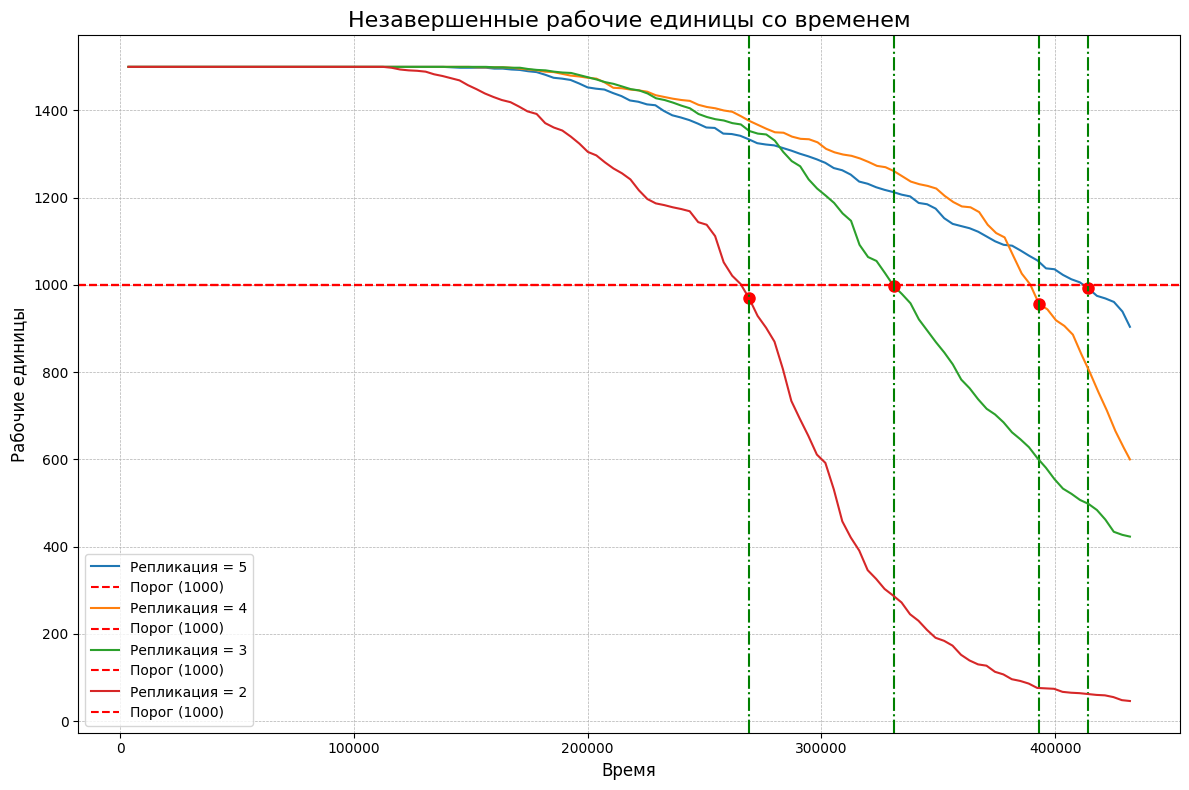

In [ ]:
# если файлы 

import os
import matplotlib.pyplot as plt

# Укажи путь к папке, где лежат твои CSV
folder_path = "D:/_Projects/_monobeh_boinc/SimulationOutput/"

fig, ax = plt.subplots(figsize=(12, 8))

min_quorum = 5

# Получаем список всех файлов в папке, фильтруем только .csv
files = [f for f in os.listdir(folder_path) if f.endswith('.csv')]

# Если файлов нет, выведем предупреждение
if not files:
    print(f"В папке '{folder_path}' не найдено CSV файлов.")
else:
    for ind, file_name in enumerate(files):
        # Собираем полный путь к файлу
        full_path = os.path.join(folder_path, file_name)
        
        try:
            # Передаем полный путь и используем ind для смещения replica
            plot_workunit_completion(ax, full_path, group_size=1000, replica=-ind + min_quorum)
            print(f"Успешно обработан: {file_name}")
        except Exception as e:
            print(f"Ошибка при обработке {file_name}: {e}")

plt.tight_layout()
plt.show()

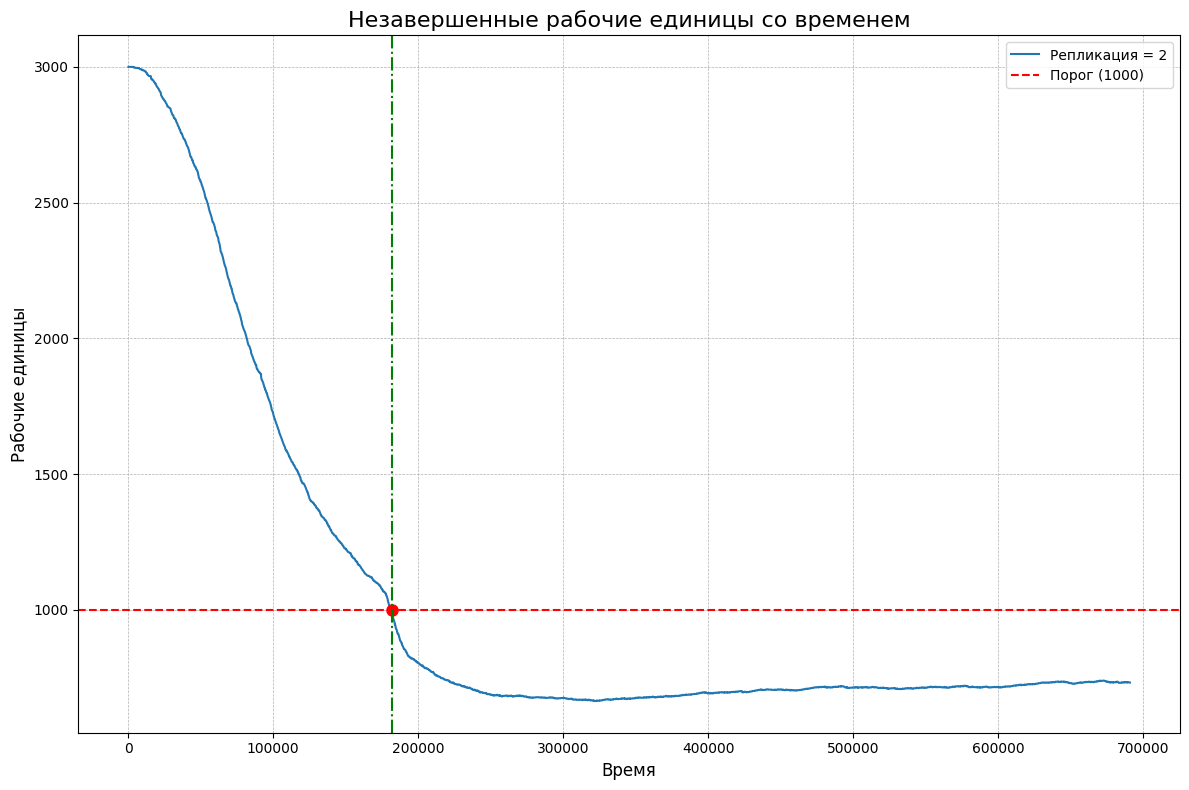

In [ ]:
import os
import matplotlib.pyplot as plt

# Путь к корневой папке, где лежат папки-таймкоды
root_dir = r"D:\_Projects\_monobeh_boinc\SimulationOutput" 
target_file = "statistics.csv" # Имя файла внутри каждой папки
min_quorum = 5

fig, ax = plt.subplots(figsize=(12, 8))

# 1. Получаем список всех элементов в папке
# 2. Оставляем только те, что являются папками (таймкоды)
subfolders = [f for f in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, f))]

# Сортируем папки (по алфавиту/времени), чтобы графики шли по порядку
subfolders.sort()

for ind, folder_name in enumerate(subfolders):
    # Формируем путь: корневая/таймкод/workunits.csv
    file_path = os.path.join(root_dir, folder_name, target_file)
    
    if os.path.exists(file_path):
        try:
            # Передаем полный путь к файлу
            # В качестве метки или доп. инфо можно использовать folder_name
            plot_workunit_completion(ax, file_path, group_size=1000, replica=-ind + min_quorum)
            print(f"Успешно обработан: {folder_name}/{target_file}")
        except Exception as e:
            print(f"Ошибка в файле из {folder_name}: {e}")
    else:
        print(f"Файл не найден в папке: {folder_name}")

plt.tight_layout()
plt.show()